___
# Gallstone Prediction Project
___ 

## Aim: Make a classification model that predict gallstone status (Yes/No) from 38 clinical and bioimpedance features
 
Group xx:                                   
 - Haakon 
 - Marius 
 - Magnus 
 - Sebastian
 - Jacob


### Setter opp miljøet som tillater oss å kjøre, her henter vi bibloteker vi skal bruke

* pandas brukes til å lese inn data og gjøre dataanalyse
* sklearn brukes til å lage modeller og evaluere dem med accuracy_score osv.
* seaborn brukes til å lage heatmaps og andre visualiseringer
* matplotlib brukes til plotting og analyse

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk


## Initial Data Review

In this section, we examine the shape of the dataset and verify whether it contains any missing values or duplicate rows.

In [7]:
# Initial Data Review
df = pd.read_csv("dataset-uci.csv", sep=";",decimal=",")
data = pd.read_csv("dataset-uci.csv", sep=";", decimal=",")

print("Shape:", df.shape)

display(df.head(20))

print("\nData types:")
display(df.dtypes)

print("\nFeatures:")
print(df.columns.tolist())

print("\nMissing values per column:")
display(df.isnull().sum(axis=0))

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Shape: (319, 39)


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.00,16.0,33.00
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.00,14.4,25.00
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.00,16.2,30.20
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.00,15.4,35.40
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.00,16.8,40.60
5,0,96,0,0,0,0,0,0,155,49.0,...,30.0,65.0,13.0,13.0,60.0,1.46,43.74,0.00,11.0,45.80
6,0,37,0,0,0,0,0,0,185,67.1,...,40.0,60.0,15.0,14.0,72.0,0.77,118.25,0.00,13.8,20.00
7,0,41,0,0,0,0,0,0,176,114.0,...,34.0,464.0,26.0,28.0,69.0,1.30,73.73,0.11,16.5,24.50
8,0,38,0,0,0,0,0,0,186,93.7,...,33.0,679.0,68.0,102.0,70.0,0.91,110.63,1.57,16.5,22.70
9,0,38,0,0,0,0,0,0,171,68.6,...,43.0,129.0,19.0,34.0,75.0,0.91,110.63,0.00,16.6,15.60



Data types:


Gallstone Status                                    int64
Age                                                 int64
Gender                                              int64
Comorbidity                                         int64
Coronary Artery Disease (CAD)                       int64
Hypothyroidism                                      int64
Hyperlipidemia                                      int64
Diabetes Mellitus (DM)                              int64
Height                                              int64
Weight                                            float64
Body Mass Index (BMI)                             float64
Total Body Water (TBW)                            float64
Extracellular Water (ECW)                         float64
Intracellular Water (ICW)                         float64
Extracellular Fluid/Total Body Water (ECF/TBW)    float64
Total Body Fat Ratio (TBFR) (%)                   float64
Lean Mass (LM) (%)                                float64
Body Protein C


Features:
['Gallstone Status', 'Age', 'Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)', 'Height', 'Weight', 'Body Mass Index (BMI)', 'Total Body Water (TBW)', 'Extracellular Water (ECW)', 'Intracellular Water (ICW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)', 'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)', 'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)', 'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)', 'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)', 'Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)', 'High Density Lipoprotein (HDL)', 'Triglyceride', 'Aspartat Aminotransferaz (AST)', 'Alanin Aminotransferaz (ALT)', 'Alkaline Phosphatase (ALP)', 'Creatinine', 'Glomerular Filtration Rate (GFR)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']

Missing values per column:


Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)                         0
Bone Mass (B


Number of duplicate rows:
0


### Initial Data Review Summary

The dataset contains 319 observations and 39 columns. The features include demographic information, medical conditions, body composition measurements, and laboratory test results.

No missing values were found in the dataset, and no duplicate rows were identified. Therefore, no handling of missing data or removal of duplicate observations is required at this stage.

## Cleaning

In [ ]:
# Compute correlation matrix
correlation_matrix = df.corr()    

plt.figure(figsize=(14,12))
sns.heatmap(
    correlation_matrix,
    annot=False,       # Remove numbers
    cmap="warm",   # Color map
    cbar=True,         # Show color bar
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# Extract correlation with Gallstone Status
gallstone_corr = correlation_matrix['Gallstone Status'].drop('Gallstone Status')

# Sort features by absolute correlation strength
gallstone_corr_sorted = gallstone_corr.abs().sort_values(ascending=False)

# Display
print(f"Features sorted by correlation to gallstone: \n\n{gallstone_corr_sorted}")

# Extract top 5 most correlated features (absolute values)
top5_features = gallstone_corr_sorted.head(5).index.tolist()

plt.figure(figsize=(10,8))
sns.barplot(
    x=gallstone_corr_sorted.values,
    y=gallstone_corr_sorted.index,
    hue=gallstone_corr_sorted.index,  # assign y to hue
    palette='coolwarm',
)
plt.title('Feature Correlation with Gallstone Status')
plt.xlabel('Correlation Coefficient (absolute)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



KeyError: "'warm' is not a valid value for colormap. Did you mean one of: 'coolwarm', 'coolwarm_r', 'bwr'?"

<Figure size 1400x1200 with 0 Axes>

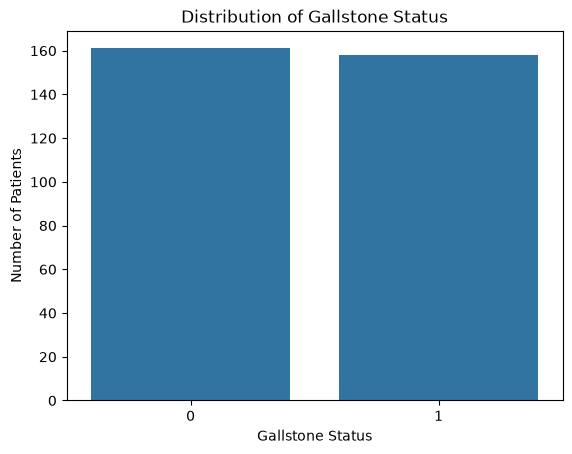

In [9]:
sns.countplot(
    data=df,
    x="Gallstone Status"
)

plt.title("Distribution of Gallstone Status")
plt.xlabel("Gallstone Status")
plt.ylabel("Number of Patients")
plt.show()

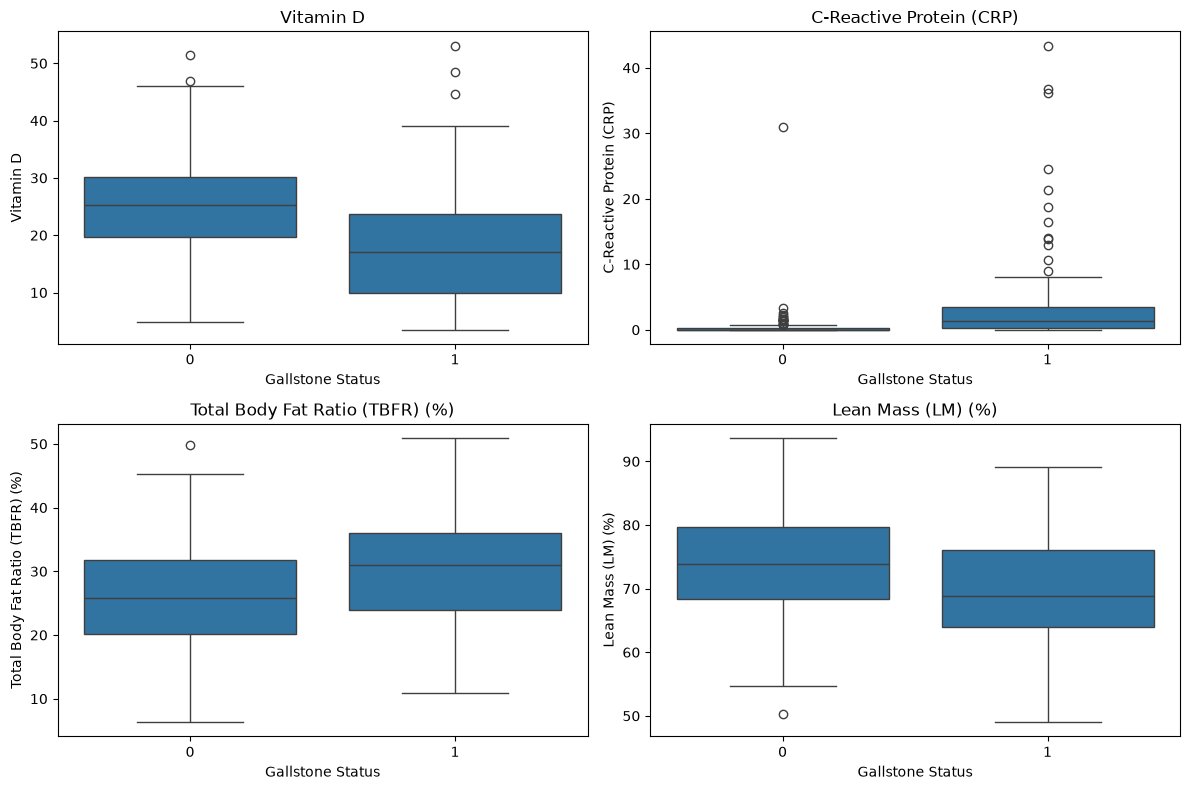

In [10]:
features = [
    "Vitamin D",
    "C-Reactive Protein (CRP)",
    "Total Body Fat Ratio (TBFR) (%)",
    "Lean Mass (LM) (%)"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for feature, ax in zip(features, axes.flatten()):

    sns.boxplot(
        data=df,
        x="Gallstone Status",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Gallstone Status")

plt.tight_layout()
plt.show()

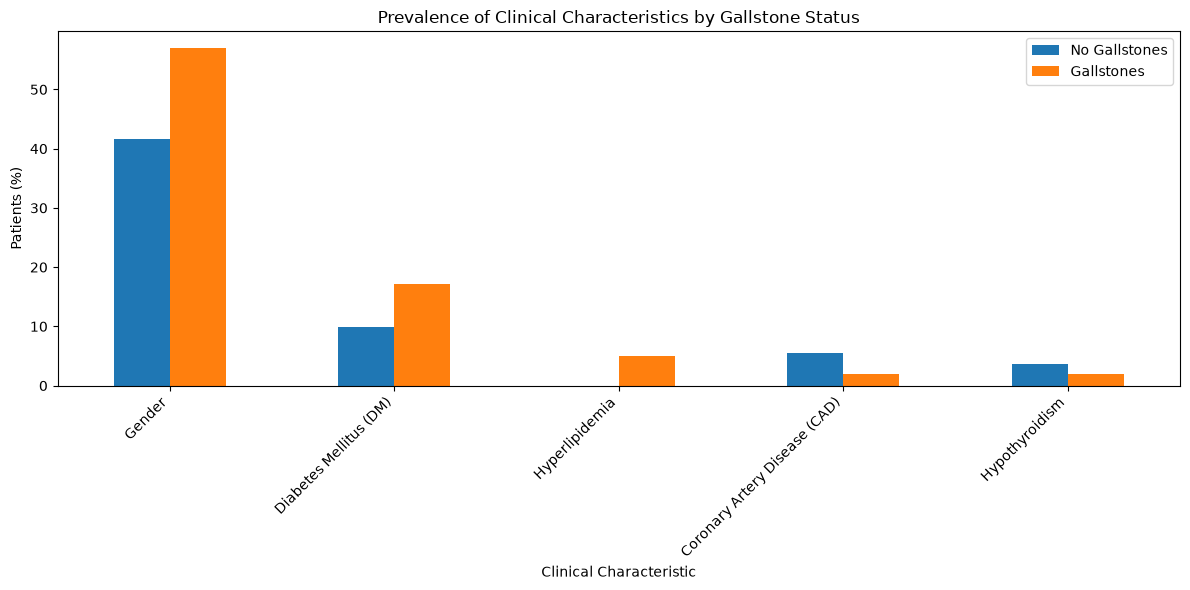

In [11]:
categorical_features = [
    "Gender",
    "Diabetes Mellitus (DM)",
    "Hyperlipidemia",
    "Coronary Artery Disease (CAD)",
    "Hypothyroidism"
]

proportions = (
    df.groupby("Gallstone Status")[categorical_features]
      .mean()
      .T * 100
)

proportions.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Prevalence of Clinical Characteristics by Gallstone Status")
plt.ylabel("Patients (%)")
plt.xlabel("Clinical Characteristic")
plt.xticks(rotation=45, ha="right")
plt.legend(["No Gallstones", "Gallstones"])
plt.tight_layout()
plt.show()